Olá, Fabrício

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:

<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>


###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição
- Você programa bem
    
<span class="text-danger">Porém, há espaço para melhorias conforme os itens apontados anteriormente. Destaco os  pontos a seguir: </span>
 * <span class="text-danger"> Alguams visualizações estão ausentes, infelizmente não posso aprovar sem essas visualizações </span>


Portanto, sugiro que você corrija os pontos indicados.
    
Se você tiver alguma dúvida sobre de algo que você não tenha entendido, sinta-se à vontade para perguntar ao tutor ou deixar um comentário em **azul** para que, na próxima iteração, eu possa responder.

Conte conosco. Lembre-se de que você pode tirar dúvidas com revisores usando os comentários ou buscar ajuda de um tutor.
Bom trabalho. 


</div>





<div class="alert alert-block alert-warning">
<b> Comentário do revisor v2: </b> <a class="tocSkip"></a>

Oi Fabrício,

- Houve grande evolução no projeto. Parabéns pelo empenho.
- Peço desculpas, mas um gráfico ficou ausente na pergunta do tempo de retorno. Para te ajudar e você não gastar muito tempo, eu deixei um código de exemplo para você adaptar. Infelizmente, não posso aprovar sem essa visualização. Peço desculpas pois deu devia ter sinalizado antes.
- O gráfico do ROMI (pelo menos) precisa ser calculado para cada coorte. Deixei código de exemplo para te ajudar.
- Este projeto é bastante interessante e desafiador; está muito alinhado com o mercado, pois gestores têm interesse em métricas do negócio. Vale a pena o investimento em visualizações. Sempre recomendo este livro: Storytelling com Dados: um Guia Sobre Visualização de Dados Para Profissionais de Negócios
</div>


<div class="alert alert-block alert-success">
<b> Comentário Geral do Revisor Final: </b> <a class="tocSkip"></a>

Tudo certo agora. Desejo sucesso na jornada. Parabéns pelo empenho.
</div>



# Análise de Uso de Y.Afisha

Nome: Fabrício Camacho

Data: 18/05/2025

## Objetivo
O presente projeto tem como objetivo analisar o uso do aplicativo Y.Afisha, entendendo o comportamento do usuário através de compras realizadas e estimar quando as depesas de marketing deverão ser cobertas pela receita do produto. Temos como objetivos específicos:
- Descobrir as métricas do uso do produto: quantas pessoas usam-no por cada dia, semana e mês; quantas sessões ocorrem por dia (um usuário pode realizar várias sessões); quanto tempo dura cada sessão em média, e com que frequência os usuários voltam a usar o produto.
- Descobrir métricas de vendas: quando as pessoas começam a comprar; quantos pedidos os clientes fazem durante um determinado período de tempo; qual é o volume médio de uma compra e quanto dinheiro eles trazem para a empresa?
- Entender os indicadores de marketing: quanto dinheiro foi gasto (no total, por origem e ao longo do tempo); quanto custou a aquisição de clientes para cada origem e entender se os investimentos valeram a pena.

## Verificação e preparação de dados

### Importando bibliotecas

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Verificando dados

In [78]:
# Criando dataframes temporários para análise de possível otimização:
visits = pd.read_csv('/datasets/visits_log_us.csv', nrows=500)
orders = pd.read_csv('/datasets/orders_log_us.csv', nrows=500)
costs = pd.read_csv('/datasets/costs_us.csv', nrows=500)

# Imprimindo dados checando memória real
print(visits.info(memory_usage='deep'))
print()
print(orders.info(memory_usage='deep'))
print()
print(costs.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Device     500 non-null    object
 1   End Ts     500 non-null    object
 2   Source Id  500 non-null    int64 
 3   Start Ts   500 non-null    object
 4   Uid        500 non-null    uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 113.1 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   500 non-null    object 
 1   Revenue  500 non-null    float64
 2   Uid      500 non-null    uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 45.0 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sou

Observações:
- O nome das colunas dos data frames "visits" e "orders" contém caracteres maiúsculos, minúsculos e espaço. Iremos mudar para o padrão snake_like.
- Colunas "Start Ts" e "End Ts" em "visits", "Buy Ts" em "orders" e "dt" em "costs": contém informações de data e hora, mas estão identificados como tipo "object". É necessário mudar para tipo DateTime;
- A colunas "Devide" e "Source Id": Podem se tratar de dados categóricos. É necessário verificar se de fato são categóricos e mudar o seu tipo de acordo com o que de fato representam.

### Otimizando dados para importação
Checando colunas "Device" e "Source Id" em "visits" para verificação de presença de categorias objetivando posterior otimização.

In [79]:
# Verificando possíveis categorias em "Device"
print(visits['Device'].value_counts())
print()
print(visits['Source Id'].value_counts())


desktop    363
touch      137
Name: Device, dtype: int64

4     159
3     122
5      92
2      52
1      39
9      19
10     17
Name: Source Id, dtype: int64


In [80]:
# Verificando possíveis categorias em "Source Id"
print(visits['Source Id'].value_counts())


4     159
3     122
5      92
2      52
1      39
9      19
10     17
Name: Source Id, dtype: int64


Observação:
De fato as colunas apresentam categorias. A transformação para tipo category é possível. Agora, faremos a mudança do nome de cada coluna para que obedeçam o padrão "snake_like" e, em seguida, mudaremos "Device" e "Source_Id" para tipo category.

In [81]:
# Importando dados otimizados e corrigidos para formato snake_like
df_visits = pd.read_csv('/datasets/visits_log_us.csv',
                        dtype={'Device': 'category'},
                        parse_dates=['Start Ts', 'End Ts']).rename(columns=lambda x: x.lower().replace(' ', '_'))
df_orders = pd.read_csv('/datasets/orders_log_us.csv', 
                        parse_dates=['Buy Ts']).rename(columns=lambda x: x.lower().replace(' ', '_'))
df_costs = pd.read_csv('/datasets/costs_us.csv', parse_dates=['dt'])

# Checando resultado de otimização de dados
print(df_visits.info(memory_usage='deep'))
print()
print(df_orders.info(memory_usage='deep'))
print()
print(df_costs.info(memory_usage='deep'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 en

In [82]:
# Mudando a coluna "source_id" para tipo category
df_costs['source_id'] = df_costs['source_id'].astype('category')
df_costs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   category      
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 42.7 KB


## Calculando métricas

### Métricas de Produto
Aqui temos os seguintes objetivos:
- Calcular quantas pessoas usam o produto por dia, por semana e por mês;
- Calcular quantas sessões ocorrem por dia;
- Calcular quanto tempo dura cada sessão (ASL);
- Calcular a frequência em que os usuários voltam a usar o produto.

#### Número de pessoas usando o produto

In [83]:
# Criando colunas contendo ano, mês, semana e dia de início de cada sessão usando a coluna "start_ts" de df_visits
df_visits['session_year'] = df_visits['start_ts'].dt.year # Criando coluna com ano.
df_visits['session_month'] = df_visits['start_ts'].dt.to_period('M') # Criando coluna com mês.
df_visits['session_week'] = df_visits['start_ts'].dt.week # Criando coluna com semana.
df_visits['session_date'] = df_visits['start_ts'].dt.date # Criando coluna com dia.

# Calculando métricas de produto DAU, WAU e MAU
dau_total = df_visits.groupby('session_date').agg({'uid': 'nunique'}).mean()
wau_total = df_visits.groupby(['session_year', 'session_week']).agg({'uid': 'nunique'}).mean()
mau_total = df_visits.groupby(['session_year', 'session_month']).agg({'uid': 'nunique'}).mean()

# Imprimindo métricas
print('Número de usuários por dia em média:', int(dau_total))
print('Número de usuários por semana em média:', int(wau_total))
print('Número de usuários por mês em média:', int(mau_total))
print('Taxa de retenção (DAU/WAU):', int(dau_total) / int(wau_total))


Número de usuários por dia em média: 907
Número de usuários por semana em média: 5716
Número de usuários por mês em média: 23228
Taxa de retenção (DAU/WAU): 0.1586773967809657


In [84]:
# Criando tabelas para calcular DAU, WAU e MAU
dau = df_visits.groupby('session_date').agg({'uid': 'nunique'})
wau = df_visits.groupby('session_week').agg({'uid': 'nunique'})
mau = df_visits.groupby('session_month').agg({'uid': 'nunique'})


<div class="alert alert-block alert-warning">
<b> Comentário do revisor v2: </b> <a class="tocSkip"></a>

Eu ajustei o gráfico WAU para melhor visualização, pois fica difícil interpretar a semana em número. Segue abaixo
</div>


<div class="alert alert-block alert-info">
<b>Resposta do Aluno:</b> <a class="tocSkip"></a>
Obrigado! Apaguei o que plotei e deixei esse.
</div>


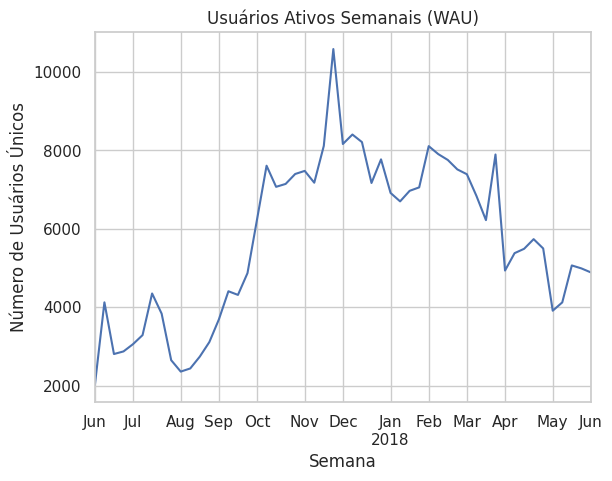

In [85]:
# Criando gráfico de usuários ativos semanais (WAU)
wau_plot_data = df_visits.groupby(df_visits['start_ts'].dt.to_period('W'))['uid'].nunique()
wau_plot_data.plot(kind='line')
plt.title('Usuários Ativos Semanais (WAU)')
plt.xlabel('Semana')
plt.ylabel('Número de Usuários Únicos')
plt.grid(True)
plt.show()


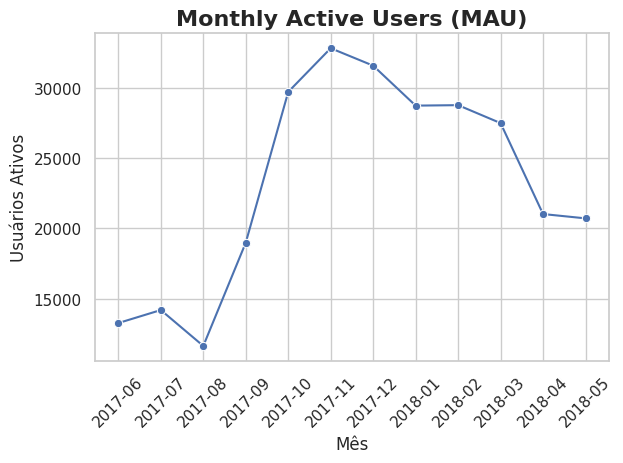

In [86]:
# Criando gráfico para MAU
mau['session_month'] = mau.index.strftime('%Y-%m')
sns.lineplot(data=mau, x='session_month', y='uid', marker='o', palette='coolwarm')
plt.title('Monthly Active Users (MAU)', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Usuários Ativos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Número e duração de sessões

In [87]:
# Entendendo o número de sessões por dia e por usuário
session_per_user = df_visits.groupby('session_date').agg({'uid': ['count', 'nunique']})
session_per_user.columns = ['n_sessions', 'n_users']
session_per_user['sessions_per_user'] = (session_per_user['n_sessions'] / session_per_user['n_users'])

# Imprimindo métricas
print('Número de sessões por dia em média:', int(session_per_user['n_sessions'].mean()))
print('Número de sessões por usuário por dia em média:', session_per_user['sessions_per_user'].mean())


Número de sessões por dia em média: 987
Número de sessões por usuário por dia em média: 1.082169644003972


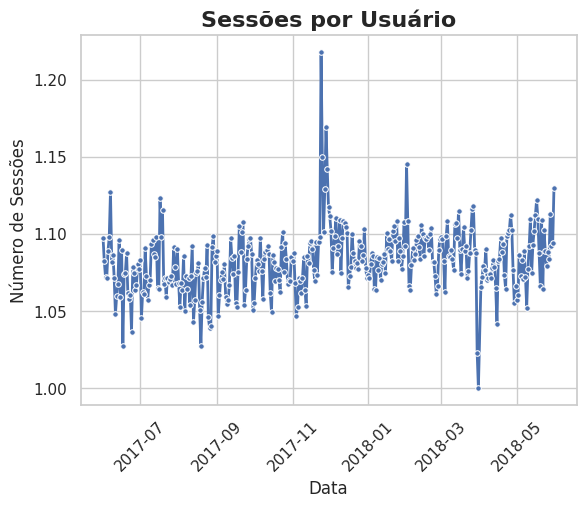

In [88]:
# Criando gráfico de número de sessões médio por usuário por dia
sns.lineplot(data=session_per_user, x='session_date', y='sessions_per_user', marker='o', linewidth=2, markersize=4)
plt.title('Sessões por Usuário', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Sessões', fontsize=12)
plt.xticks(rotation=45)
plt.show()



In [89]:
# Calculando a duração média de cada sessão (ASL)
df_visits['session_duration_sec'] = (df_visits['end_ts'] - df_visits['start_ts']).dt.seconds
print('Duração média de cada sessão (ASL):', df_visits['session_duration_sec'].mean(), 'segundos')


Duração média de cada sessão (ASL): 643.506488592098 segundos


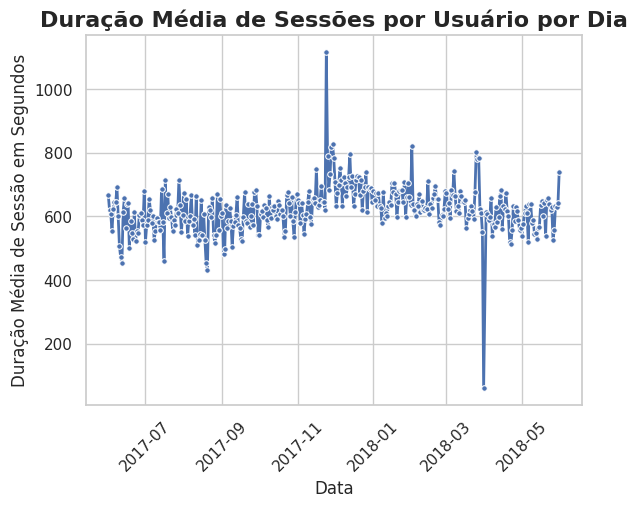

In [90]:
# Criando tabelas de duração média de sessões por unidade de tempo (dia, semana ou mês)
daily_session_duration = df_visits.groupby('session_date').agg({'session_duration_sec': 'mean'})
weekly_session_duration = df_visits.groupby('session_week').agg({'session_duration_sec': 'mean'})
monthly_session_duration = df_visits.groupby('session_month').agg({'session_duration_sec': 'mean'})



# Criando gráficos de duração média de sessões por usuário por dia
sns.lineplot(data=daily_session_duration, x='session_date', y='session_duration_sec', marker='o', linewidth=2, markersize=4)
plt.title('Duração Média de Sessões por Usuário por Dia', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Duração Média de Sessão em Segundos', fontsize=12)
plt.xticks(rotation=45)
plt.show()




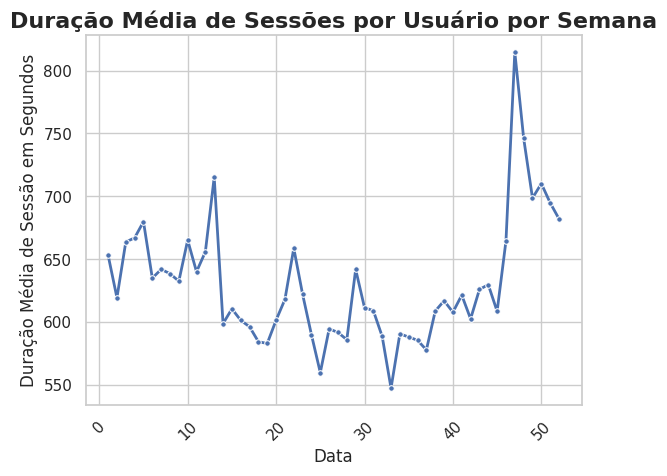

In [91]:

# Criando gráficos de duração média de sessões por usuário por semana
sns.lineplot(data=weekly_session_duration, x='session_week', y='session_duration_sec', marker='o', linewidth=2, markersize=4)
plt.title('Duração Média de Sessões por Usuário por Semana', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Duração Média de Sessão em Segundos', fontsize=12)
plt.xticks(rotation=45)
plt.show()



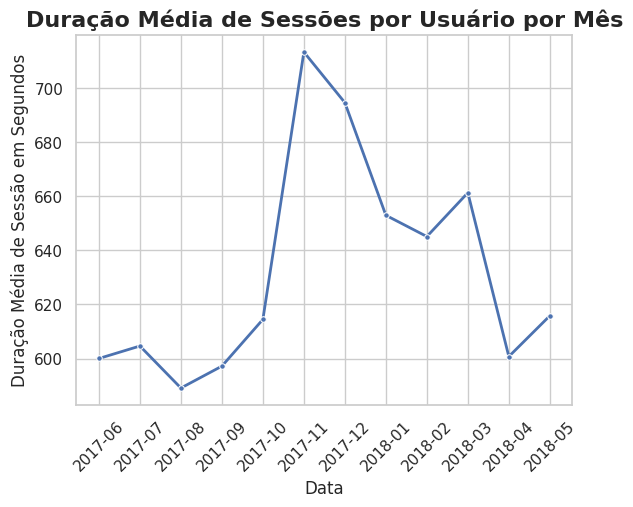

In [92]:
# Criando gráficos de duração média de sessões por usuário por mês
monthly_session_duration['session_month'] = monthly_session_duration.index.strftime('%Y-%m')
sns.lineplot(data=monthly_session_duration, x='session_month', y='session_duration_sec', marker='o', linewidth=2, markersize=4)
plt.title('Duração Média de Sessões por Usuário por Mês', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Duração Média de Sessão em Segundos', fontsize=12)
plt.xticks(rotation=45)
plt.show()


Observações: Foi possível observar que há uma média de 907 usuários da plataforma por dia, 5.716 usuários por semana e 23.228 usuários por mês, apresentando assim uma taxa de retenção de 0,16, o que pode ser considerado baixo. Além disso, 987 sessões são realizadas por dia em média, apresentando uma média 1 acesso por usuário por dia. A duração média dos usuários por sessão equivale a 643 segundos.

#### Tempo de retorno de usuários

In [93]:
# Ordenando dados por uid e tempo de início de sessão.
df_sorted_visits = df_visits.sort_values(by=['uid', 'start_ts'])

# Encontrando diferença de tempo entre acessos por usuário.
df_sorted_visits['time_diff'] = df_sorted_visits.groupby('uid')['start_ts'].diff()

# Removendo a primeira linha de cada usuário, pois não há tempo de retorno para primeiro acesso.
df_sorted_visits = df_sorted_visits.dropna(subset=['time_diff'])

# Calculando a média de tempo de retorno de usuários.
mean_return_time = df_sorted_visits['time_diff'].mean()

# Imprimindo resultado.
print(f"Tempo médio de retorno: {mean_return_time}")

Tempo médio de retorno: 28 days 02:38:40.740526247


Observação: Usuários voltam a usar o produto a cada 28 dias em média.

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Precisa plotar gŕafico linha para DAU, WAU e MAU, númeor diário de sessões por usúarios (n_sessions / n_users), duranção da sessão
- Lembre-se de que uma imagem vale mais do que mil tabelasm
</div>




<div class="alert alert-block alert-info">
<b>Resposta do Aluno:</b> <a class="tocSkip"></a>
Gráficos criados acima.
</div>




<div class="alert alert-block alert-danger">
<b> Comentário do revisor v2: </b> <a class="tocSkip"></a>

- Os gráficos de DAU, e MAU estão corretos. Parabéns
- Precisamos plotar um heatmap (apresentando para cada coorte) para a responder a pergunta do tempo de retorno. Deixo dica abaixo
</div>

<div class="alert alert-block alert-info">
<b>Resposta do Aluno:</b> <a class="tocSkip"></a>
Obrigado mais uma vez!
</div>


<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

Correto
</div>



Agora vamos entender a taxa de retenção mensal por cohorts

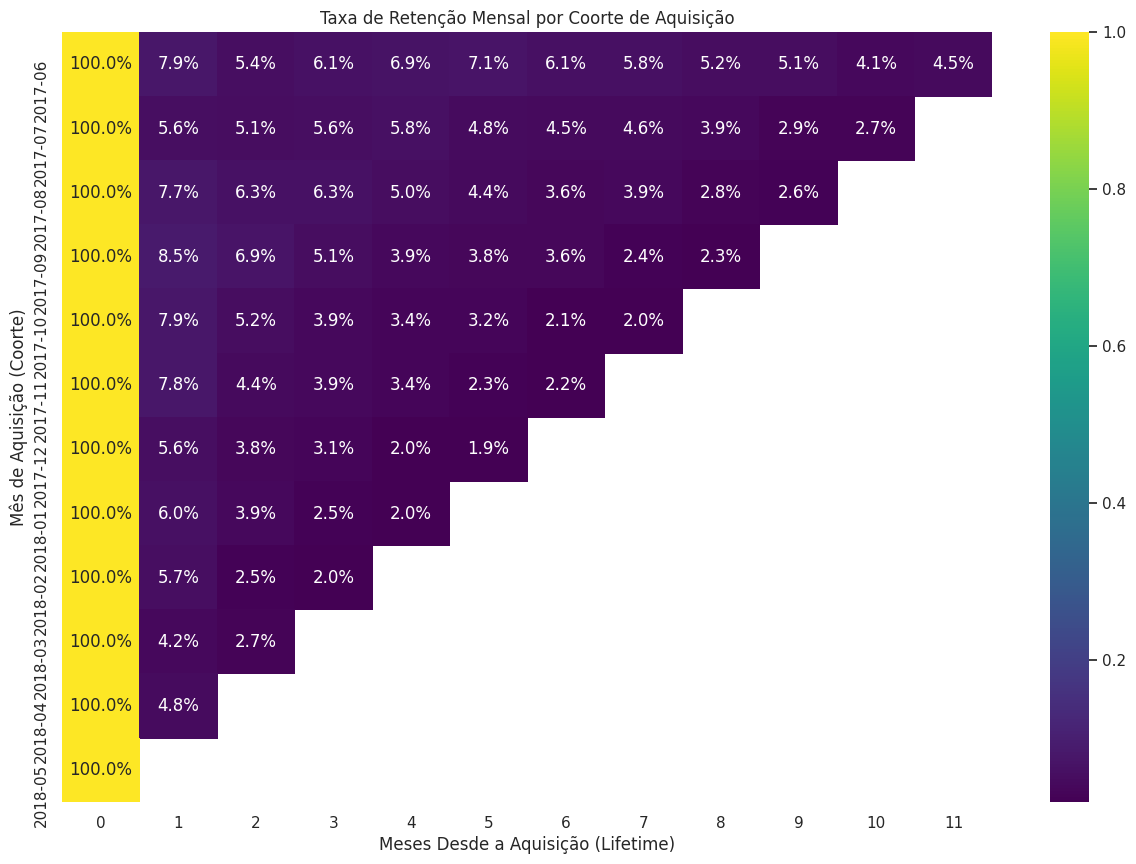

In [94]:
# Determinando o mês de aquisição de cada usuário (primeira sessão)
df_visits['acquisition_month'] = df_visits.groupby('uid')['start_ts'].transform('min').dt.to_period('M')
df_visits['session_month'] = df_visits['start_ts'].dt.to_period('M')

# Calculando a "idade" do coorte para cada sessão
df_visits['cohort_lifetime'] = (df_visits['session_month'] - df_visits['acquisition_month']).apply(lambda x: x.n)

# Tabela de coortes (pivot table)
cohorts = df_visits.groupby(['acquisition_month', 'cohort_lifetime'])['uid'].nunique().reset_index()
cohorts_pivot = cohorts.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='uid')

# Calculando a retenção em percentual
cohort_size = cohorts_pivot.iloc[:, 0]
retention_matrix = cohorts_pivot.divide(cohort_size, axis=0)

# Gerando o mapa de calor de retenção
plt.figure(figsize=(15, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='viridis')
plt.title('Taxa de Retenção Mensal por Coorte de Aquisição')
plt.xlabel('Meses Desde a Aquisição (Lifetime)')
plt.ylabel('Mês de Aquisição (Coorte)')
plt.show()


### Métricas de Venda
Aqui temos os seguintes objetivos:
- Saber quando as pessoas começam a comprar;
- Saber quantos pedidos os clientes fazem durante um determinado período de tempo;
- Saber o volume médio de uma compra;
- Calcular quanto em dinheiro os clientes trazem para a empresa (LTV).

Para dar seguimento aos objetivos, primeiramente vamos entender como tempo que as pessoas começam a comprar, o tempo que elas levam entre a inscrição no site e a sua primeira compra. Para isso vamos entender esse tempo e verificar se há grupos de pessoas para cada tempo detectado.

#### Entendendo tempo em que os clientes levam para começar a comprar.
Vamos identificar a primeira visita e a primeira compra de cada usuário e calcular o tempo entre esses dois eventos.

In [95]:
# Vamos encontrar a primeira visita de cada cliente:
first_visit = df_visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.rename(columns={'start_ts': 'first_visit_ts'}, inplace=True)

# Encontrando a primeira compra de cada usuário:
first_order = df_orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.rename(columns={'buy_ts': 'first_order_ts'}, inplace=True)

# Juntando as duas tabelas criadas:
user_behavior = pd.merge(first_visit, first_order, on='uid', how='left')

# Calculando o tempo entre a primeira visita e a primeira compra:
user_behavior['time_to_first_purchase'] = (user_behavior['first_order_ts'] - user_behavior['first_visit_ts']).dt.days

# Imprimindo informações sobre o resultado:
print(user_behavior.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 228169 entries, 0 to 228168
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   uid                     228169 non-null  uint64        
 1   first_visit_ts          228169 non-null  datetime64[ns]
 2   first_order_ts          36523 non-null   datetime64[ns]
 3   time_to_first_purchase  36523 non-null   float64       
dtypes: datetime64[ns](2), float64(1), uint64(1)
memory usage: 8.7 MB
None


Observação: É possível verificar que extistem muitos clientes que entram no site, mas não realizam compras. Para estudarmos somente aqueles que fazem compras, vamos retirar todos aqueles que visitaram o site e não fizeram.

In [96]:
# Removendo linhas onde 'time_to_first_purchase' é NaT ou NaN:
user_behavior_clean = user_behavior.dropna(subset=['time_to_first_purchase'])

# Verificando resultado
print(user_behavior_clean.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 36523 entries, 3 to 228162
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   uid                     36523 non-null  uint64        
 1   first_visit_ts          36523 non-null  datetime64[ns]
 2   first_order_ts          36523 non-null  datetime64[ns]
 3   time_to_first_purchase  36523 non-null  float64       
dtypes: datetime64[ns](2), float64(1), uint64(1)
memory usage: 1.4 MB
None


In [97]:
# Entendendo os dados de tempo entre a primeira visita e a primeira compra:
print(user_behavior_clean['time_to_first_purchase'].describe())


count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: time_to_first_purchase, dtype: float64


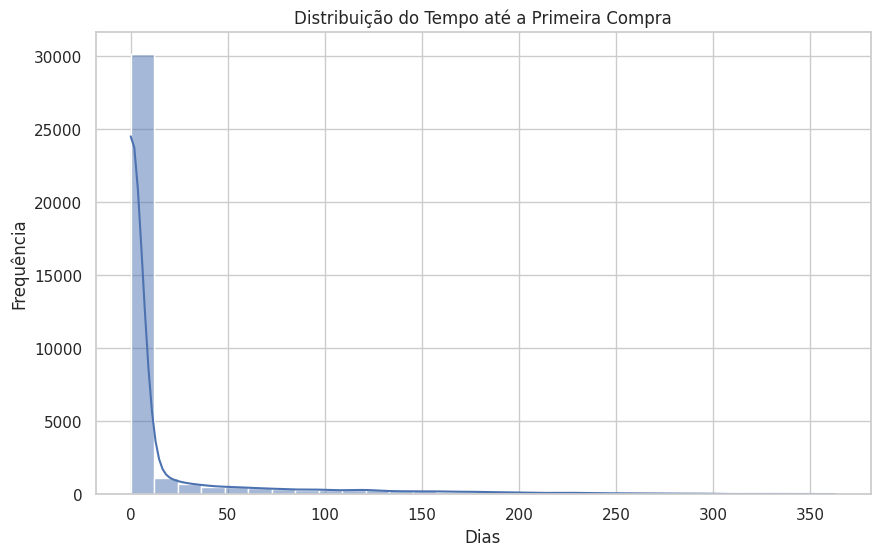

In [98]:
# Verificando a distribuição do tempo até a primeira compra
plt.figure(figsize=(10, 6))
sns.histplot(user_behavior_clean['time_to_first_purchase'].dropna(), bins=30, kde=True)
plt.title('Distribuição do Tempo até a Primeira Compra')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.show()


Observação: É possível notar que grande parte dos clientes que fazem compras as fazem no mesmo dia da sua primeira sessão no site.

#### Entender número de pedidos por tempo
Aqui iremos entender como funiciona o comportamento dos clientes a cada mês em termos de quantidade de compras. Para isso, dividiremos os clientes em cohorts mensais para visualizar particularidades.

In [99]:
# Contando número de pedidos por cliente
orders_per_user = df_orders.groupby('uid')['buy_ts'].count().reset_index()
orders_per_user.rename(columns={'buy_ts': 'number_of_orders'}, inplace=True)

print(orders_per_user['number_of_orders'].describe())

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: number_of_orders, dtype: float64


In [100]:
# Criando uma coluna com o mês da primeira compra de cada cliente.
df_orders['first_purchase_month'] = df_orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')

# Criando coluna com o mês de cada pedido
df_orders['purchase_month'] = df_orders['buy_ts'].dt.to_period('M')

# Calculando número de meses desde a primeira compra
df_orders['months_since_first_purchase'] = (df_orders['purchase_month'] - df_orders['first_purchase_month']).apply(lambda x: x.n)

# Agrupar por cohort e meses desde a primeira compra
cohort_data = df_orders.groupby(['first_purchase_month', 'months_since_first_purchase'])['uid'].nunique().reset_index()

# Renomear colunas
cohort_data.rename(columns={'uid': 'number_of_users'}, inplace=True)

# Criando tabela dinâmica (pivot table) para a matriz de cohorts
cohort_pivot = cohort_data.pivot_table(
    index='first_purchase_month',
    columns='months_since_first_purchase',
    values='number_of_users').fillna("")

# Imprimindo tabela dinânima
cohort_pivot


months_since_first_purchase,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2017-06,2023.0,61.0,50.0,54.0,88.0,67.0,62.0,47.0,58.0,45.0,45.0,53.0
2017-07,1923.0,52.0,57.0,64.0,49.0,38.0,36.0,39.0,42.0,22.0,26.0,
2017-08,1370.0,58.0,53.0,44.0,40.0,32.0,30.0,44.0,19.0,31.0,,
2017-09,2581.0,130.0,100.0,74.0,52.0,64.0,66.0,37.0,43.0,,,
2017-10,4340.0,206.0,123.0,92.0,93.0,72.0,56.0,67.0,,,,
2017-11,4081.0,222.0,120.0,106.0,81.0,48.0,62.0,,,,,
2017-12,4383.0,146.0,103.0,97.0,50.0,63.0,,,,,,
2018-01,3373.0,114.0,83.0,43.0,45.0,,,,,,,
2018-02,3651.0,118.0,58.0,39.0,,,,,,,,


Observação: É possível notar que geralmente as cohortes apresentam número expressivo no início, porém o número de clientes que voltam a comprar é muito baixo em relação ao mês zero de cada cohort, o que sugere que a retenção de clientes ao produto é baixa.

#### Entendendo o volume médio das compras.
Utilizando os dados fornecidos, é possível calcular o volume médio de compras na plataforma.Porém, primeiramente, vamos entender como os dados de volume de vendas se comportam calculando a estatística básica da receita por usuário (soma total gasto por cada um).

In [101]:
# Calculando estatística da receita por usuário (soma total gasto por cada um)
user_revenue = df_orders.groupby('uid')['revenue'].sum().describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

print(user_revenue)


count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
10%          0.730000
25%          1.470000
50%          3.050000
75%          5.800000
90%         10.750000
95%         16.250000
max      11810.180000
Name: revenue, dtype: float64


Observação: É possível constatar algumas coisas:
1. O volume médio de uma compra é de $ 6.901328;
2. O valor máximo é muito maior que 95%, mostrando que há outliers e que alguns poucos clientes apresentam grande volume de compras;
3. A média é bem 40% maior que a mediana, o que demonstra que os dados são assimétricos e tendem para a direita;
4. A grande maioria dos dados encontram-se entre 0 e 16, o que demonstra que a maioria dos clientes apresentam baixo volume de compras.

A média dos dados não os representa bem, o que pode ser verificado pela diferença entre a média e a mediana (50%). Desta forma, vamos verificar o volume médio dos dados considerando as cohorts mensais mencionadas anteriormente e entender suas variações.

In [102]:
# Criando tabela para formação de cohorts considerando valor monetário usado na plataforma.
cohort_revenue = df_orders.groupby(['first_purchase_month', 'months_since_first_purchase'])['revenue'].sum().reset_index()

# Criando tabela dinâmica:
cohort_revenue_pivot = cohort_revenue.pivot_table(
    index='first_purchase_month', 
    columns='months_since_first_purchase', 
    values='revenue').fillna("")

cohort_revenue_pivot


months_since_first_purchase,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2017-06,9557.49,981.82,885.34,1931.3,2068.58,1487.92,1922.74,1176.56,1119.15,1225.51,1155.66,519.62
2017-07,11557.65,644.61,1199.05,690.31,339.97,300.08,231.16,272.72,310.05,282.96,299.36,
2017-08,7228.83,646.63,628.12,536.05,676.85,388.45,288.61,554.86,400.33,257.53,,
2017-09,14568.53,2884.49,1344.52,10261.52,1033.84,1670.08,1810.85,627.57,474.92,,,
2017-10,21716.20,2325.21,830.65,682.01,657.77,522.37,368.1,501.14,,,,
2017-11,21036.26,1629.27,814.39,1326.13,604.04,219.88,469.02,,,,,
2017-12,20767.49,1141.22,4054.7,4669.1,1371.57,1481.66,,,,,,
2018-01,13949.50,994.22,1026.34,481.59,211.48,,,,,,,
2018-02,15177.16,1015.98,286.66,270.7,,,,,,,,


É possível observar que as cohorts diminuem o volume de dinheiro gasto na plataforma com o tempo. Esse dado agora serã usado para calcular o LTV (Lifetime Value) de cada cohort e entendermos com quanto cada cliente contribui em média para a empresa em cada cohort.

#### Calculando o LTV.
Primeiramente, vamos calcular o ticket médio de cada cohort por mês de vida para entendermos os valores gastos por pessoa em cada período e em cada cohort. Em seguida, calcularemos o LTV acumulando os gastos mensais de cada cohort de acordo com seu tempo de vida total.

In [103]:
# Juntando tabelas para calcular o ticket médio
df_ltv = pd.merge(left = cohort_data, right = cohort_revenue, on = ['first_purchase_month', 'months_since_first_purchase'])

# Calculando ticket médio das cohorts por mês
df_ltv['mean_ticket'] = df_ltv['revenue'] / df_ltv['number_of_users']

# Gerando matriz de cohorts com os dados de ticket médio
cohort_mean_ticket_pivot = df_ltv.pivot_table(
    index='first_purchase_month', 
    columns='months_since_first_purchase', 
    values='mean_ticket').fillna("")

# Imprimindo resultado
cohort_mean_ticket_pivot


months_since_first_purchase,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2017-06,4.724414,16.09541,17.7068,35.764815,23.506591,22.207761,31.011935,25.033191,19.29569,27.233556,25.681333,9.804151
2017-07,6.010218,12.396346,21.035965,10.786094,6.938163,7.896842,6.421111,6.992821,7.382143,12.861818,11.513846,
2017-08,5.276518,11.148793,11.851321,12.182955,16.92125,12.139063,9.620333,12.610455,21.07,8.307419,,
2017-09,5.644529,22.188385,13.4452,138.669189,19.881538,26.095,27.437121,16.961351,11.044651,,,
2017-10,5.003733,11.287427,6.753252,7.413152,7.072796,7.255139,6.573214,7.479701,,,,
2017-11,5.154683,7.339054,6.786583,12.51066,7.457284,4.580833,7.564839,,,,,
2017-12,4.738191,7.816575,39.366019,48.135052,27.4314,23.518413,,,,,,
2018-01,4.135636,8.721228,12.365542,11.199767,4.699556,,,,,,,
2018-02,4.156987,8.61,4.942414,6.941026,,,,,,,,


In [104]:
df_orders.head()

,buy_ts,revenue,uid,first_purchase_month,purchase_month,months_since_first_purchase
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,2017-06,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,2017-06,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,2017-06,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06,2017-06,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06,2017-06,0


In [105]:
# Gerando matriz de cohorts com os dados de LTV médio
cohort_ltv_pivot = df_ltv.pivot_table(
    index='first_purchase_month', 
    columns='months_since_first_purchase', 
    values='mean_ticket')

# Inserindo valores acumulados do mês anterior em cada cohort para calcular LTV
cohort_ltv_pivot = cohort_ltv_pivot.cumsum(axis = 1).fillna("")

# Imprimindo resultado
cohort_ltv_pivot


months_since_first_purchase,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2017-06,4.724414,20.819824,38.526624,74.291439,97.79803,120.005791,151.017726,176.050918,195.346608,222.580163,248.261497,258.065647
2017-07,6.010218,18.406565,39.442529,50.228623,57.166786,65.063629,71.48474,78.47756,85.859703,98.721521,110.235367,
2017-08,5.276518,16.425311,28.276632,40.459587,57.380837,69.519899,79.140232,91.750687,112.820687,121.128106,,
2017-09,5.644529,27.832914,41.278114,179.947303,199.828842,225.923842,253.360963,270.322314,281.366965,,,
2017-10,5.003733,16.29116,23.044412,30.457564,37.53036,44.785499,51.358713,58.838414,,,,
2017-11,5.154683,12.493737,19.28032,31.79098,39.248264,43.829098,51.393936,,,,,
2017-12,4.738191,12.554766,51.920785,100.055837,127.487237,151.00565,,,,,,
2018-01,4.135636,12.856864,25.222406,36.422174,41.121729,,,,,,,
2018-02,4.156987,12.766987,17.709401,24.650427,,,,,,,,


Diante dos resultados acima é importante observar que:
1. Cohorts em seu primeiro mês de vida tem seu ticket médio entre 3.42 e 5.64, mas costumam aumentar seu ticket médio nos meses seguintes;
2. As cohorts de 2017_06 e 2017_09 apresentaram valores similares de LTV (258.06 e 281.36, respectivamente) apesar do tempo de vida entre elas ser diferente em 3 meses. Provavelmente as estratégias adotadas para a última cohort obtiveram bons resultados.

### Métricas de Marketing
Agora vamos entender os custos de marketing. Para isso precisamos responder as seguintes questões:
1. Quanto dinheiro foi gasto em cada mês para cada origem?
2. Ao total, quanto custou a aquisição de clientes para cada origem?
3. Entender se os investimentos valeram a pena calculando o ROI.

#### Valor monetário por origem por mês


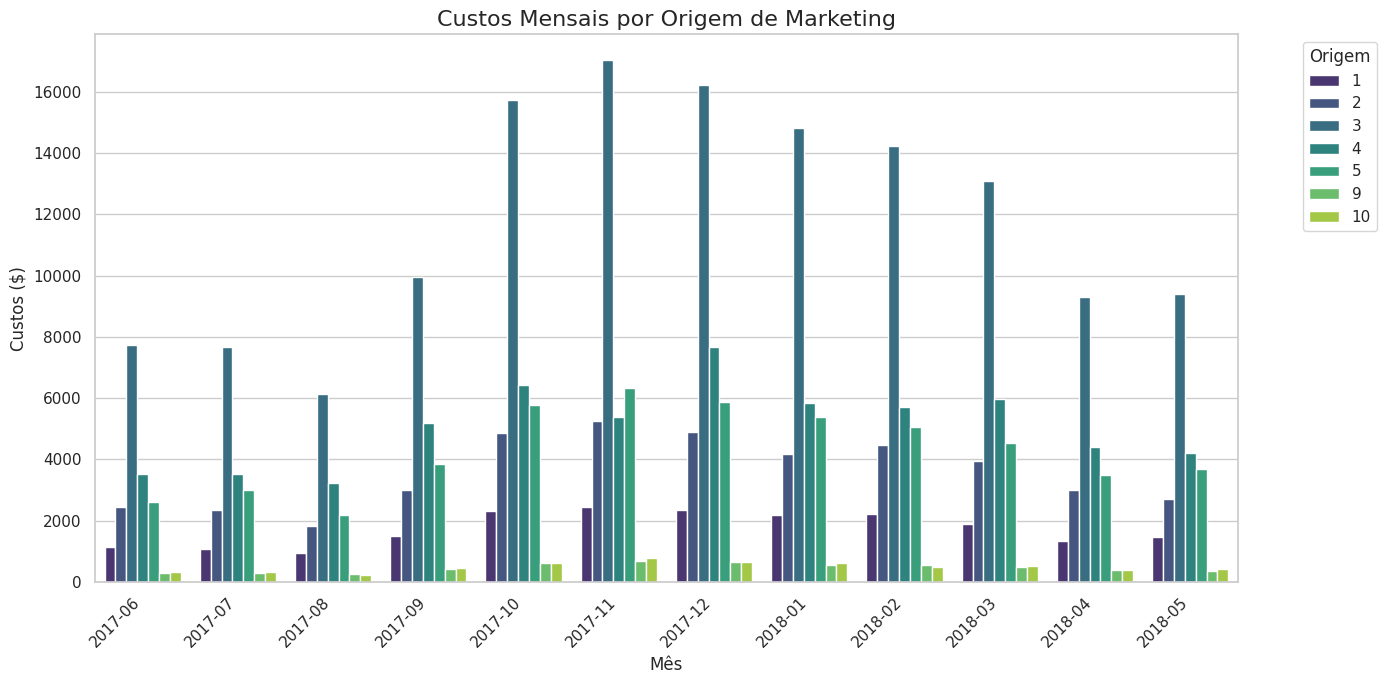

In [106]:
# Criando coluna para representar o mês referente ao custo com marketing
df_costs['dt_month'] = df_costs['dt'].dt.to_period('M')

# Agrupando custos por categoria de origem (source_id) e por mês
df_monthly_costs = df_costs.groupby(['source_id', 'dt_month'])['costs'].sum().reset_index()

# Criar o gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
sns.barplot(data=df_monthly_costs, 
            x='dt_month', 
            y='costs', 
            hue='source_id',
            palette='viridis')

# Personalizações
plt.title('Custos Mensais por Origem de Marketing', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Custos ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotaciona os labels do eixo x
plt.legend(title='Origem', bbox_to_anchor=(1.05, 1), loc='upper left')  # Legenda fora do gráfico

# Ajustar layout para não cortar rótulos
plt.tight_layout()
plt.show()


Observações: Diante do gráfico que mostra os custos mensais por origem de marketing, podemos observar:
1. Entre outubro de 2017 e março de 2018 houve um aumento nos investimentos em marketing comparado aos demais meses;
2. A origem 3 é a que representa maior custo em todos os meses, comparando-se com as demais origens;
3. As origens 4, 5, 2 e 1 representam os maiores gastos com marketing seguido da origem 3;
4. Somente em novembro de 2017 a origem 5 foi maior que 4 e 2, mas não foi superior que a origem 3;
5. As origens 9 e 10 são as que representam o menor custo em todos os períodos analisados.

#### Custo de aquisição de clientes para cada origem
Agora vamos entender de maneira geral, os custos do cliente para cada categoria no período analisado.


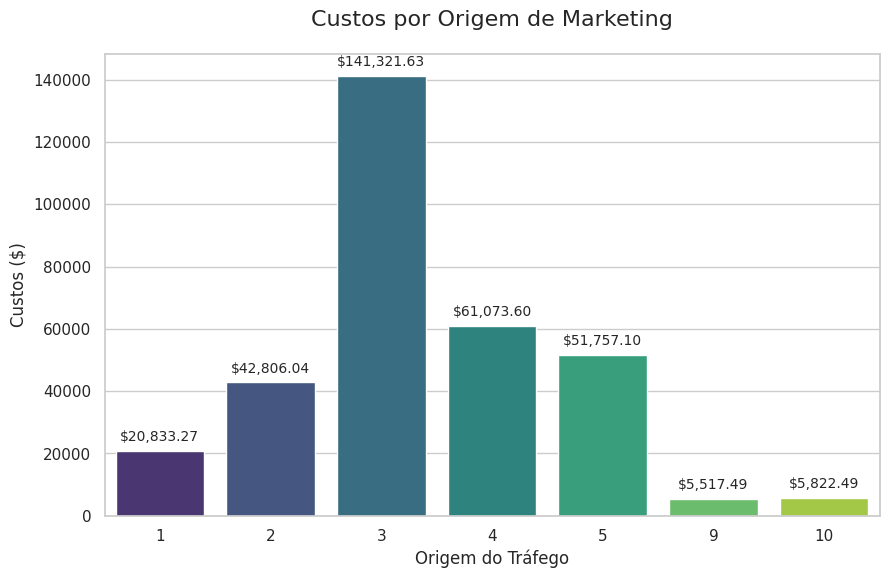

In [107]:
# Criando tabela com informações de custos totais por origem
df_source_costs = df_monthly_costs.groupby('source_id')['costs'].sum().reset_index()

# Criar o gráfico de barras
sns.set(style="whitegrid")  # Fundo com grid
plt.figure(figsize=(10, 6))  # Tamanho do gráfico
ax = sns.barplot(
    data=df_source_costs,
    x='source_id',
    y='costs',
    palette="viridis",  # Paleta de cores moderna
    estimator=sum,      # Soma os valores (útil se houver duplicatas)
    ci=None            # Remove intervalos de confiança
)

# Personalizações
plt.title('Custos por Origem de Marketing', fontsize=16, pad=20)
plt.xlabel('Origem do Tráfego', fontsize=12)
plt.ylabel('Custos ($)', fontsize=12)

# Adicionar valores nas barras
for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.2f}',  # Formata como valor monetário
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=10
    )


Observações: Ao analisar os custos gerais por categoria, as observações com relação a relevância dos custos por categoria de origem se confirmaram, sendo a origem 3 aquela com maior custo, seguidas das origens 4, 5, 2 e 1. As origens 9 e 10 representam o menor custo dentre todas as demais.

#### Entendendo se os investimentos em marketing valeram a pena (CAC e ROI)
Primeiramente, vamos entender quanto cada cliente custou em cada cohort analisada. Logo em seguida. Assim será possível compreender se os investimentos valeram a pena calculando o ROI após isso.


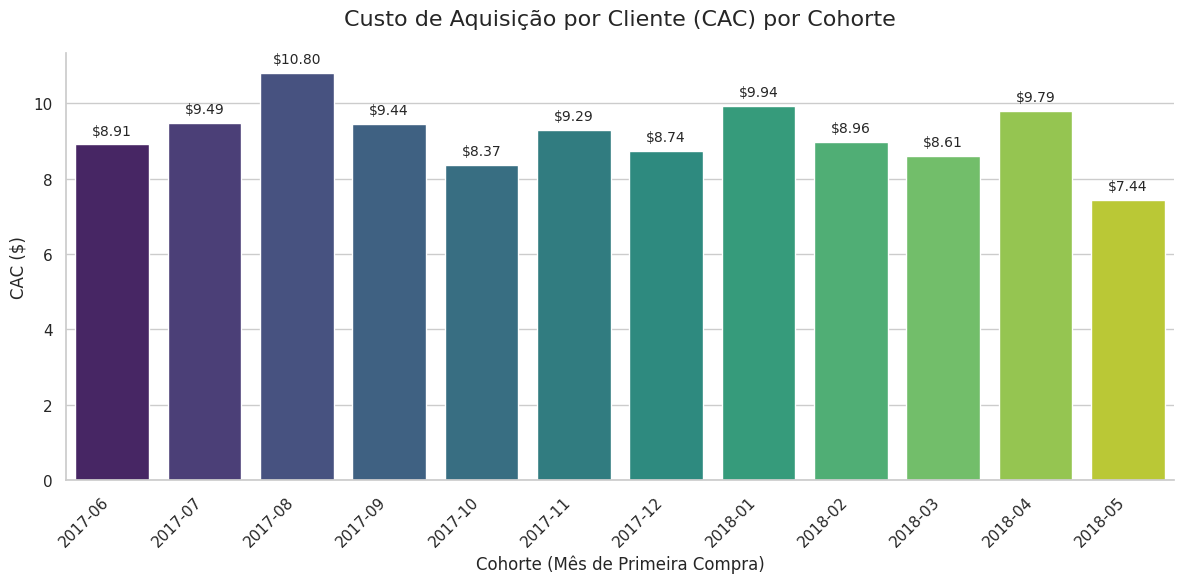

In [108]:
# Criando tabela com o custo total para cada cohort
df_costs_per_month = df_monthly_costs.groupby('dt_month')['costs'].sum().reset_index()

# Criando tabela com o número de usuários da plataforma em cada cohort
df_users_per_cohort = cohort_data[cohort_data['months_since_first_purchase'] == 0].drop(columns=['months_since_first_purchase'])

# Criando tabela com o LTV de cada cohort
df_ltv_real = df_ltv.groupby('first_purchase_month')['mean_ticket'].sum().reset_index()
df_ltv_real = df_ltv_real.rename(columns={'mean_ticket': 'ltv'})

# Juntando tabelas com dados de Economia Unitária de cada cohort
df_temp = pd.merge(left = df_ltv_real, right = df_costs_per_month, left_on = 'first_purchase_month', right_on = 'dt_month').drop(columns=['dt_month'])
df_unit_economics = pd.merge(left = df_temp, right = df_users_per_cohort, on = 'first_purchase_month')
df_unit_economics = df_unit_economics.rename(columns={'first_purchase_month': 'cohort'})

# Calculando CAC e inserindo em tabela de Economia Unitária
df_unit_economics['cac'] = df_unit_economics['costs'] / df_unit_economics['number_of_users']

# Criar o gráfico de barras para visualização de CACs por cohort
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_unit_economics,
    x='cohort',
    y='cac',
    palette="viridis",  # Paleta de cores
    estimator=sum,      # Garante que estamos somando os valores
    ci=None            # Remove barras de erro
)

# Personalizações do gráfico
plt.title('Custo de Aquisição por Cliente (CAC) por Cohorte', fontsize=16, pad=20)
plt.xlabel('Cohorte (Mês de Primeira Compra)', fontsize=12)
plt.ylabel('CAC ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotaciona os rótulos do eixo x

# Adicionar valores nas barras
for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.2f}',  # Formata como valor monetário
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=10
    )

# Ajustar layout e mostrar
sns.despine()
plt.tight_layout()
plt.show()


Observação: É possível observar que o valor de CAC flutua entre 7.44 e 10.80. Agora vamos calcular o valor do ROI e comparar o mesmo considerando cada cohort.

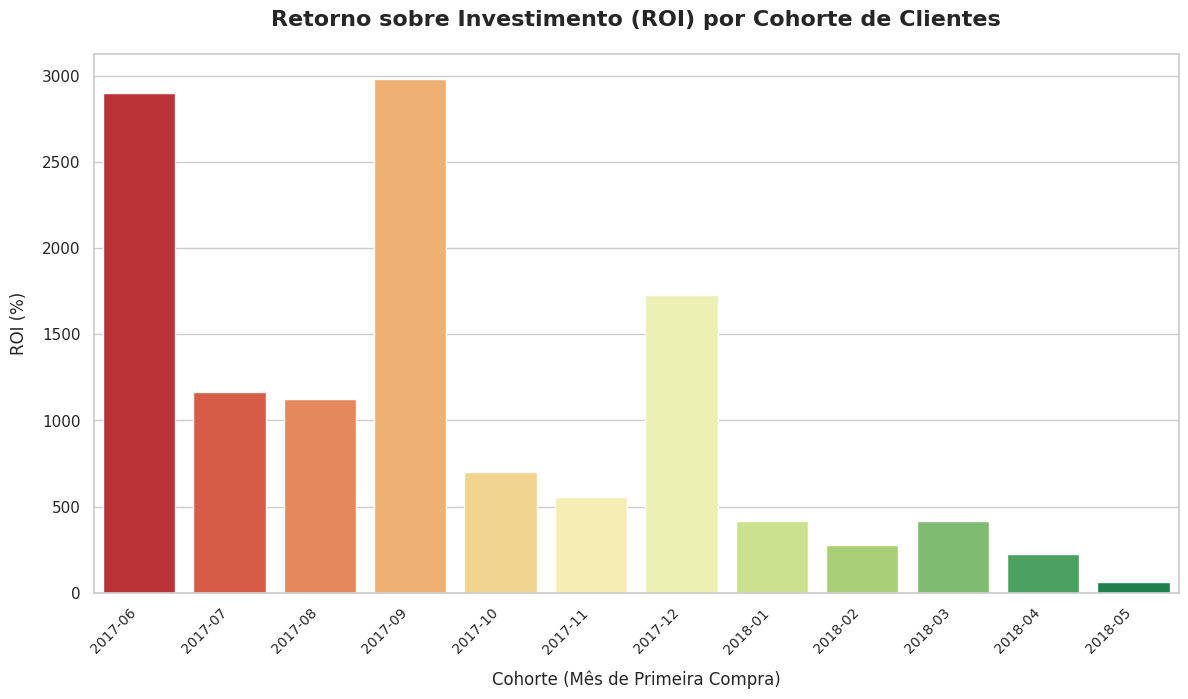

In [109]:
# Calculando ROI para cada cohort
df_unit_economics['roi'] = df_unit_economics['ltv'] * 100 / df_unit_economics['cac']

# Criar o gráfico de barras para visualização de ROI por cohorts
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_unit_economics,
    x='cohort',
    y='roi',
    palette="RdYlGn",
    saturation=0.8
)

# Personalizações
plt.title('Retorno sobre Investimento (ROI) por Cohorte de Clientes', 
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Cohorte (Mês de Primeira Compra)', fontsize=12, labelpad=10)
plt.ylabel('ROI (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.show()


Observações: É possivel notar pelo gráfico acima que os ROIs das cohorts de setembro de 2017 e de dezembro de 2017 foram elevados comparando com o padrão que as demais cohorts apresentam. É interessante tentar entender quais acontecimentos ou estratégias aconteceram nesses meses para que tais cohorts tenham apresentado esse comportamento.

Agora vamos calcular os valores de CAC, LTV e ROI médios, que representam todo o período estudado.

In [110]:
# Calculando CAC médio
cac = df_unit_economics['cac'].mean()

# Calculando LTV médio
ltv = df_unit_economics['ltv'].mean()

# Calculando ROI médio
roi = ltv * 100 / cac

# Imprimindo resultados
print('LTV médio:', '$', int(ltv))
print('CAC médio:', '$', int(cac))
print('ROI médio:', int(roi), '%')

LTV médio: $ 96
CAC médio: $ 9
ROI médio: 1057 %


<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Precisa plotar ROMI para cada source similar à matriz do LTV que você plotou (eixo x a idade, eixo y o tempo decorrido/idade)
</div>


<div class="alert alert-block alert-info">
<b>Resposta do Aluno:</b> <a class="tocSkip"></a>
ROMI foi calculado abaixo.
</div>


<div class="alert alert-block alert-danger">
<b> Comentário do revisor v2: </b> <a class="tocSkip"></a>

Precisa calcular o ROMI para cada coorte (eu escrevi errado acima, coloquei source em vez de coorte). Para ajudar, deixo o código abaixo.
</div>


<div class="alert alert-block alert-info">
<b>Resposta do Aluno:</b> <a class="tocSkip"></a>
Obrigado pelo auxílio. Esse sprint me deixou com a cabeça fumaçando, mas consegui compreender.
</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

Esse projeto é bastante desafiador. Porém, está muito alinhado com o mercado. Eu atuo como cientista de dados e, por várias vezes, meu gerente me pediu gráficos complexos pois ele precisava apresentar numa reunião para o gerente dele. Gestores querem visualizar indicadores do negócio. É o que você está fazendo neste projeto.
</div>



#### Entendendo ROMI para cada Cohort
Agora vamos entender se os investimentos valeram a pena calculando o ROMI para cada uma das cohorts.

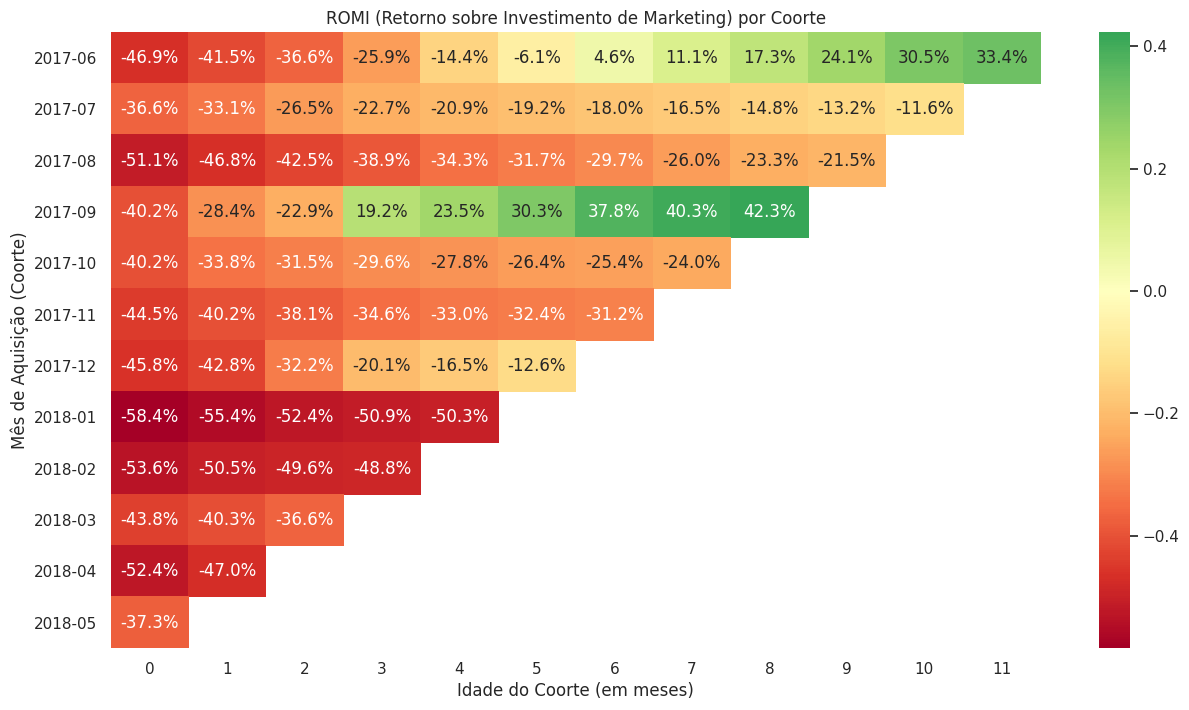

In [111]:
# LTV acumulado por coorte
df_orders['acquisition_month'] = df_orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')
df_orders['order_month'] = df_orders['buy_ts'].dt.to_period('M')
df_orders['cohort_lifetime'] = (df_orders['order_month'] - df_orders['acquisition_month']).apply(lambda x: x.n)
cohorts_revenue = df_orders.groupby(['acquisition_month', 'cohort_lifetime'])['revenue'].sum().reset_index()
cohort_sizes = df_orders.groupby('acquisition_month')['uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']
cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')
cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']
ltv_pivot = cohorts_data.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='ltv').cumsum(axis=1)

# CAC por coorte (mês de aquisição)
df_costs['month'] = df_costs['dt'].dt.to_period('M')
first_orders = df_orders.sort_values('buy_ts').drop_duplicates('uid')
first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')
n_buyers_by_cohort = first_orders.groupby('acquisition_month')['uid'].nunique().reset_index()
n_buyers_by_cohort.columns = ['month', 'n_buyers']
costs_by_cohort = df_costs.groupby('month')['costs'].sum().reset_index()
cac_by_cohort = pd.merge(costs_by_cohort, n_buyers_by_cohort, on='month')
cac_by_cohort['cac'] = cac_by_cohort['costs'] / cac_by_cohort['n_buyers']
cac_by_cohort = cac_by_cohort[['month', 'cac']]
cac_by_cohort.columns = ['acquisition_month', 'cac']

# Juntando o CAC com a tabela de LTV
report = pd.merge(ltv_pivot.reset_index(), cac_by_cohort, on='acquisition_month')
report = report.set_index('acquisition_month')

# Obtendo a coluna de CAC e as colunas de LTV
cac_values = report['cac']
ltv_values = report.drop(columns=['cac'])

# Calculando o ROMI para cada mês da vida do coorte
romi_pivot = ltv_values.subtract(cac_values, axis=0).divide(cac_values, axis=0)

# Mapa de calor do ROMI
plt.figure(figsize=(15, 8))
sns.heatmap(romi_pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0)
plt.title('ROMI (Retorno sobre Investimento de Marketing) por Coorte')
plt.xlabel('Idade do Coorte (em meses)')
plt.ylabel('Mês de Aquisição (Coorte)')
plt.show()


<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

Correto
</div>



Através da observação do heatmap é possível notar que somente as cohorts de junho e setembro de 2017 apresentaram retorno do valor investido, sendo junho apresentando valores positivos após 6 meses e o de setembro após 3.

#### Entendendo ROMI para cada fonte de marketing.
Aqui vamos tentar entender o retorno sobre investimento de marketing para cada fonte (source) existente nos dados.

<div class="alert alert-block alert-info">
<b>Resposta do Aluno:</b> <a class="tocSkip"></a>
Você acha que devo deixar esse heatmap que criei para cada fonte? Achei um dado relevante para o relatório... ou acha melhor retirar?
</div>

<div class="alert alert-block alert-success">
<b> Comentário do revisor V3: </b> <a class="tocSkip"></a>

Acho que deve deixar. Agrega valor. É uma outra forma de visualizar os dados
</div>



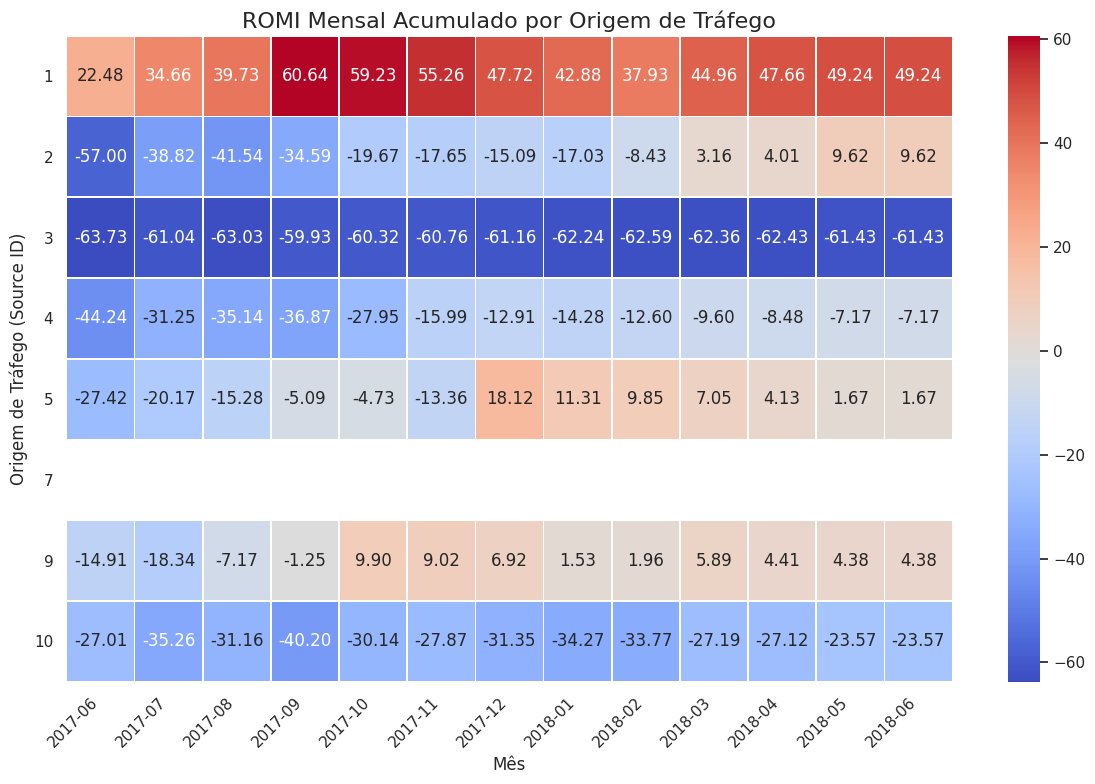

In [112]:
# Unindo dados de visitas e pedidos para encontrar a origem da primeira visita de cada usuário.
first_visit_with_source = df_visits.sort_values('start_ts').drop_duplicates('uid')
orders_with_source = pd.merge(df_orders, first_visit_with_source[['uid', 'source_id']], on='uid', how='left')

# Calcular a receita mensal por origem.
monthly_revenue = orders_with_source.groupby(['source_id', 'purchase_month'])['revenue'].sum().reset_index()
monthly_revenue_pivot = monthly_revenue.pivot_table(index='source_id', columns='purchase_month', values='revenue').fillna(0)
cumulative_revenue = monthly_revenue_pivot.cumsum(axis=1)

# Calcular os custos mensais por origem.
monthly_costs = df_costs.groupby(['source_id', 'dt_month'])['costs'].sum().reset_index()
monthly_costs_pivot = monthly_costs.pivot_table(index='source_id', columns='dt_month', values='costs').fillna(0)
cumulative_costs = monthly_costs_pivot.cumsum(axis=1)

# Alinhar os DataFrames de receita e custos para o cálculo do ROMI.
all_months = sorted(list(set(cumulative_revenue.columns) | set(cumulative_costs.columns)))
aligned_cumulative_revenue = cumulative_revenue.reindex(columns=all_months, fill_value=0)
aligned_cumulative_costs = cumulative_costs.reindex(columns=all_months, fill_value=0)
aligned_cumulative_costs = aligned_cumulative_costs.replace(0, pd.NA).ffill(axis=1).fillna(0)

# Calcular o ROMI em porcentagem.
romi_matrix = ((aligned_cumulative_revenue - aligned_cumulative_costs) / aligned_cumulative_costs * 100).replace([float('inf'), -float('inf')], 0)

# Plotar o mapa de calor do ROMI.
plt.figure(figsize=(12, 8))
sns.heatmap(romi_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('ROMI Mensal Acumulado por Origem de Tráfego', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Origem de Tráfego (Source ID)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Segundo os dados de ROMI por fonte é possível observar que a fonte 1 foi a que mais apresentou retorno à empresa, sempre apresentando dados positivos em todos os meses, com maiores retornos alcaçados entre setembro e novembro de 2017. As fontes 9, 5 e 2 apresentaram resultados negativos no início e posteriormente resultados positivos, mas que não superam aqueles da fonte 1. As demais fontes não apresentaram resultados de retorno positivo.

## Conclusões e Recomendações
- Apesar da maioria dos clientes fazerem mais compras no primeiro dia de acesso, os mesmos costumam gastar mais nos meses subsequentes, mesmo que acessando menos a plataforma;
- No primeiro mês de acesso, o ticket médio dos usuários varia entre 3.42 e 5.64. Considerando o CAC de 9.00 e que o ticket médio dos clientes costuma aumentar no mês seguinte, isso significa que os os custos com clientes são cobertos a partir do seu segundo mês de vida;
- O aumento de custos com marketing no mês de setembro de 2017 gerou um aumento expressivo do ROI da mesma cohorte, o que pode significar que as estratégias adotadas podem ter sido eficientes.
- O aumento do ROI na cohort de dezembro de 2017 pode ser relacionada com o período do Natal;
- De forma geral, cada cliente traz $96.00 (LTV) para a empresa;
- Com o ROI de 1057% a empresa demonstra que consegue gerenciar bem os valores investidos em relação aos valores obtidos em sua atividade comercial.
- Somente as cohorts de junho e setembro de 2017 apresentaram retorno positivo de marketing à empresa;
- A fonte 1 apresentou melhor retorno para a empresa. Tal fonte pode ser priorizada em futuros investimentos de marketing